In [ ]:
import torch
import torch.nn as nn

In [ ]:
# Make synthetic data

In [ ]:
def make_synthetic_data(vocab_size, seq_length, num_of_seq):
  dataset = []
  for _ in range(num_of_seq):
    sequence = torch.randint(vocab_size, (seq_length//2,))
    sequence = torch.cat((sequence, sequence), dim=0)
    dataset.append(sequence)
  return torch.stack(dataset, dim=0)

In [ ]:
data = make_synthetic_data(vocab_size=52, seq_length=16, num_of_seq=5)
print(data.shape)
print(data[0])

torch.Size([5, 16])
tensor([37, 51, 46, 42, 47, 45, 16, 34, 37, 51, 46, 42, 47, 45, 16, 34])


In [ ]:
x = data[:,:-1]
y = data[:,1:]

In [ ]:
x

tensor([[37, 51, 46, 42, 47, 45, 16, 34, 37, 51, 46, 42, 47, 45, 16],
        [27, 34, 46, 14, 18, 25, 33, 46, 27, 34, 46, 14, 18, 25, 33],
        [ 0, 35,  1, 20, 23, 17, 20, 46,  0, 35,  1, 20, 23, 17, 20],
        [18, 13,  6,  3, 34, 44, 37, 42, 18, 13,  6,  3, 34, 44, 37],
        [38,  8,  8, 43, 32, 40,  8, 28, 38,  8,  8, 43, 32, 40,  8]])

In [ ]:
y

tensor([[51, 46, 42, 47, 45, 16, 34, 37, 51, 46, 42, 47, 45, 16, 34],
        [34, 46, 14, 18, 25, 33, 46, 27, 34, 46, 14, 18, 25, 33, 46],
        [35,  1, 20, 23, 17, 20, 46,  0, 35,  1, 20, 23, 17, 20, 46],
        [13,  6,  3, 34, 44, 37, 42, 18, 13,  6,  3, 34, 44, 37, 42],
        [ 8,  8, 43, 32, 40,  8, 28, 38,  8,  8, 43, 32, 40,  8, 28]])

In [ ]:
from math import sqrt
# transformer

class OneLayerTransformer(nn.Module):

  def __init__(self, vocab_size, seq_length, embedding_dim = 64, d_head = 64):
    super().__init__()
    self.vocab_size = vocab_size
    self.seq_length = seq_length
    self.embedding_dim = embedding_dim
    self.d_head = d_head
    self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
    self.pos_embedding = nn.Embedding(seq_length-1, embedding_dim)
    self.W_Q = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V = nn.Linear(embedding_dim, d_head, bias=False)
    self.output_projection = nn.Linear(d_head, vocab_size)



  def forward(self, inputs): # inputs : (batch_size, seq_length-1)
    positions = torch.arange(self.seq_length-1)
    input_token_embeddings = self.token_embedding(inputs)
    input_pos_embeddings = self.pos_embedding(positions)
    input_final_embedding = input_token_embeddings + input_pos_embeddings # batch_size, seq_len-1, num_dim
    Q = self.W_Q(input_final_embedding)
    K = self.W_K(input_final_embedding)
    V = self.W_V(input_final_embedding) # batch_size, seq_len-1, d_head
    # find attention
    scores = Q @ K.transpose(-1, -2)
    scores /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool()
    scores = scores.masked_fill(mask, float("-inf"))
    scores = torch.softmax(scores, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values = scores @ V
    return self.output_projection(values)



In [ ]:
model = OneLayerTransformer(vocab_size=52, seq_length=16)
out = model(x)
print(out.shape)  # expect (5, 15, 52)  # what do you expect this to be?

torch.Size([5, 15, 52])


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
device = torch.device('cuda')

In [ ]:
from math import sqrt
# transformer

class OneLayerTransformer(nn.Module):

  def __init__(self, vocab_size, seq_length, embedding_dim = 64, d_head = 64):
    super().__init__()
    self.vocab_size = vocab_size
    self.seq_length = seq_length
    self.embedding_dim = embedding_dim
    self.d_head = d_head
    self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
    self.pos_embedding = nn.Embedding(seq_length-1, embedding_dim)
    self.W_Q = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V = nn.Linear(embedding_dim, d_head, bias=False)
    self.output_projection = nn.Linear(d_head, vocab_size)



  def forward(self, inputs): # inputs : (batch_size, seq_length-1)
    positions = torch.arange(self.seq_length-1).to(device)
    input_token_embeddings = self.token_embedding(inputs)
    input_pos_embeddings = self.pos_embedding(positions)
    input_final_embedding = input_token_embeddings + input_pos_embeddings # batch_size, seq_len-1, num_dim
    Q = self.W_Q(input_final_embedding)
    K = self.W_K(input_final_embedding)
    V = self.W_V(input_final_embedding) # batch_size, seq_len-1, d_head
    # find attention
    scores = Q @ K.transpose(-1, -2)
    scores /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores = scores.masked_fill(mask, float("-inf")).to(device)
    scores = torch.softmax(scores, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values = scores @ V + input_final_embedding
    return self.output_projection(values)



In [ ]:
def make_synthetic_data(vocab_size, seq_length, num_of_seq):
  dataset = []
  for _ in range(num_of_seq):
    sequence = torch.randint(vocab_size, (seq_length//2,))
    sequence = torch.cat((sequence, sequence), dim=0)
    dataset.append(sequence)
  return torch.stack(dataset, dim=0)

In [ ]:
vocab_size = 52
seq_length = 16
num_of_seq = 10000

In [ ]:
embedding_dim = 64
d_head = 64

In [ ]:
# data
data = make_synthetic_data(vocab_size=vocab_size, seq_length=seq_length, num_of_seq=num_of_seq)
x = data[:,:seq_length-1]
y = data[:,1:]
dataset = TensorDataset(x,y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
# transformer
model = OneLayerTransformer(vocab_size, seq_length, embedding_dim, d_head).to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

In [ ]:
loss_func = torch.nn.CrossEntropyLoss()

In [ ]:
epochs = 100

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(len(images),len(labels))

32 32


In [ ]:
# Training Loop
for epoch in range(epochs):
  for batch_idx, (x, y) in enumerate(train_loader):
    # forward pass
    output = model.forward(x.to(device))
    # zero grad
    optimizer.zero_grad()
    # loss
    loss = loss_func(output.transpose(-1, -2), y.to(device))
    if epoch %5 == 0 and batch_idx == 0:
      print(f"epoch: {epoch}, loss = {loss}")
    # backward pass
    loss.backward()
    # grad descent / step
    optimizer.step()

epoch: 0, loss = 4.348047256469727
epoch: 5, loss = 1.9134979248046875
epoch: 10, loss = 1.88682222366333
epoch: 15, loss = 1.8590224981307983
epoch: 20, loss = 1.8878464698791504
epoch: 25, loss = 1.8613417148590088
epoch: 30, loss = 1.8744884729385376
epoch: 35, loss = 1.8523281812667847
epoch: 40, loss = 1.8616169691085815
epoch: 45, loss = 1.8776301145553589
epoch: 50, loss = 1.8711323738098145
epoch: 55, loss = 1.8547385931015015
epoch: 60, loss = 1.8623096942901611
epoch: 65, loss = 1.8659785985946655
epoch: 70, loss = 1.855056643486023
epoch: 75, loss = 1.8470513820648193
epoch: 80, loss = 1.8613454103469849
epoch: 85, loss = 1.8641606569290161
epoch: 90, loss = 1.8637714385986328
epoch: 95, loss = 1.849826693534851


In [ ]:
# evaluation
model.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    output = model.forward(x)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


10000
tensor([3.9677, 3.9304, 3.9178, 3.9208, 3.9170, 3.9154, 3.9122, 0.0455, 0.0504,
        0.0465, 0.0503, 0.0519, 0.0524, 0.0487, 0.0489])


In [ ]:
# def make_synthetic_data(vocab_size, seq_length, num_of_seq):
#   dataset = []
#   for _ in range(num_of_seq):
#     sequence = torch.randint(vocab_size, (seq_length//2,))
#     sequence = torch.cat((sequence, sequence), dim=0)
#     dataset.append(sequence)
#   return torch.stack(dataset, dim=0)
# vocab_size = 52
# seq_length = 16
# num_of_seq = 1000
# embedding_dim = 64
# d_head = 64
# # data
# data = make_synthetic_data(vocab_size=vocab_size, seq_length=seq_length, num_of_seq=num_of_seq)
# x = data[:,:seq_length-1]
# y = data[:,1:]
# dataset = TensorDataset(x,y)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


# # transformer
# model = OneLayerTransformer(vocab_size, seq_length, embedding_dim, d_head)
# optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)
# loss_func = torch.nn.CrossEntropyLoss()
# epochs = 1
# data_iter = iter(train_loader)
# images, labels = next(data_iter)
# print(len(images),len(labels))
# for epoch in range(epochs):
#   for batch_idx, (x, y) in enumerate(train_loader):
#     # Training Loop
#     # forward pass
#     if batch_idx == 0:
#       print(x)
#     output = model.forward(x)
#     if batch_idx == 0:
#       print(output.shape)
#     # zero grad
#     optimizer.zero_grad()
#     # loss
#     loss = loss_func(output.transpose(-1, -2), y)
#     if batch_idx %10 == 0:
#       print(f"{batch_idx}'s loss = {loss}")
#     # print(len(output))
#     # backward pass
#     loss.backward()
#     # grad descent / step
#     optimizer.step()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
from math import sqrt
# transformer

class TwoLayerTransformer(nn.Module):

  def __init__(self, vocab_size, seq_length, embedding_dim = 64, d_head = 64):
    super().__init__()
    self.vocab_size = vocab_size
    self.seq_length = seq_length
    self.embedding_dim = embedding_dim
    self.d_head = d_head
    self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
    self.pos_embedding = nn.Embedding(seq_length-1, embedding_dim)
    self.W_Q1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_Q2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.output_projection = nn.Linear(d_head, vocab_size)



  def forward(self, inputs): # inputs : (batch_size, seq_length-1)

    # first layer
    positions = torch.arange(self.seq_length-1).to(device)
    input_token_embeddings = self.token_embedding(inputs)
    input_pos_embeddings = self.pos_embedding(positions)
    input_final_embedding = input_token_embeddings + input_pos_embeddings # batch_size, seq_len-1, num_dim
    Q = self.W_Q1(input_final_embedding)
    K = self.W_K1(input_final_embedding)
    V = self.W_V1(input_final_embedding) # batch_size, seq_len-1, d_head
    # find attention
    scores = Q @ K.transpose(-1, -2)
    scores /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores = scores.masked_fill(mask, float("-inf"))
    scores = torch.softmax(scores, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values1 = scores @ V + input_final_embedding # batch_size, seq_len-1, d_head

    # second layer
    Q = self.W_Q2(values1)
    K = self.W_K2(values1)
    V = self.W_V2(values1) # batch_size, seq_len-1, d_head
    # find attention
    scores = Q @ K.transpose(-1, -2)
    scores /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores = scores.masked_fill(mask, float("-inf"))
    scores = torch.softmax(scores, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values = scores @ V + values1 # batch_size, seq_len-1, d_head

    return self.output_projection(values)



In [ ]:
device = torch.device('cuda')

In [ ]:
device

device(type='cuda')

In [ ]:
def make_synthetic_data(vocab_size, seq_length, num_of_seq):
  dataset = []
  for _ in range(num_of_seq):
    sequence = torch.randint(vocab_size, (seq_length//2,))
    sequence = torch.cat((sequence, sequence), dim=0)
    dataset.append(sequence)
  return torch.stack(dataset, dim=0)
vocab_size = 52
seq_length = 16
num_of_seq = 10000
embedding_dim = 64
d_head = 64
# data
data = make_synthetic_data(vocab_size=vocab_size, seq_length=seq_length, num_of_seq=num_of_seq)
x = data[:,:seq_length-1]
y = data[:,1:]
dataset = TensorDataset(x,y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
# transformer
model2 = TwoLayerTransformer(vocab_size, seq_length, embedding_dim, d_head).to(device)
model2.train()
optimizer = torch.optim.Adam(model2.parameters(),lr = 0.001)
loss_func = torch.nn.CrossEntropyLoss()
epochs = 100
# Training Loop
for epoch in range(epochs):
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    y = y.to(device)
    # forward pass
    output = model2.forward(x)
    # zero grad
    optimizer.zero_grad()
    # loss
    loss = loss_func(output.transpose(-1, -2), y)
    if epoch %5 == 0 and batch_idx == 0:
      print(f"epoch: {epoch}, loss = {loss}")
    # backward pass
    loss.backward()
    # grad descent / step
    optimizer.step()

epoch: 0, loss = 4.261773109436035
epoch: 5, loss = 1.8440158367156982
epoch: 10, loss = 1.839590072631836
epoch: 15, loss = 1.8379390239715576
epoch: 20, loss = 1.8272823095321655
epoch: 25, loss = 1.809469223022461
epoch: 30, loss = 1.8167835474014282
epoch: 35, loss = 1.808847188949585
epoch: 40, loss = 1.7888767719268799
epoch: 45, loss = 1.800373911857605
epoch: 50, loss = 1.8364118337631226
epoch: 55, loss = 1.812859296798706
epoch: 60, loss = 1.814761996269226
epoch: 65, loss = 1.7890366315841675
epoch: 70, loss = 1.7694848775863647
epoch: 75, loss = 1.7637953758239746
epoch: 80, loss = 1.7639414072036743
epoch: 85, loss = 1.8200657367706299
epoch: 90, loss = 1.7544580698013306
epoch: 95, loss = 1.7937687635421753


In [ ]:
# evaluation
model2.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    output = model2.forward(x)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


10000
tensor([3.9180e+00, 3.8255e+00, 3.7928e+00, 3.8017e+00, 3.7490e+00, 3.7222e+00,
        3.7878e+00, 7.0559e-03, 8.8854e-03, 6.2730e-03, 4.4682e-03, 2.0205e-03,
        1.4261e-03, 3.6395e-03, 4.3168e-03])


In [ ]:
test_data = make_synthetic_data(vocab_size=52, seq_length=16, num_of_seq=1000)

In [ ]:
dataset = TensorDataset(test_data[:,:-1],test_data[:,1:])
test_loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
# evaluation
model.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    output = model.forward(x)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


10000
tensor([4.0233, 4.0140, 4.0145, 4.0070, 4.0053, 4.0125, 4.0000, 0.0519, 0.0580,
        0.0541, 0.0542, 0.0544, 0.0622, 0.0480, 0.0454])


In [ ]:
# evaluation
model2.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    output = model2.forward(x)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


10000
tensor([3.9180e+00, 3.8255e+00, 3.7928e+00, 3.8017e+00, 3.7490e+00, 3.7222e+00,
        3.7878e+00, 7.0559e-03, 8.8854e-03, 6.2730e-03, 4.4682e-03, 2.0205e-03,
        1.4261e-03, 3.6395e-03, 4.3168e-03])


In [ ]:
# evaluation
model.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(test_loader):
    x = x.to(device)
    output = model.forward(x)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


1000
tensor([4.0301, 4.0104, 4.0186, 3.9891, 4.0137, 4.0086, 3.9722, 0.0555, 0.0574,
        0.0597, 0.0515, 0.0543, 0.0585, 0.0433, 0.0667])


In [ ]:
# evaluation
model2.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(test_loader):
    x = x.to(device)
    output = model2.forward(x)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


1000
tensor([4.0042e+00, 4.0945e+00, 4.1173e+00, 4.1282e+00, 4.1666e+00, 4.2071e+00,
        4.1206e+00, 8.4345e-03, 1.4644e-02, 9.1750e-03, 5.6766e-03, 2.0562e-03,
        1.5743e-03, 3.7697e-03, 1.1040e-02])


In [ ]:
# now we will visualize this

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
device = torch.device('cuda')

In [ ]:
from math import sqrt
# transformer

class TwoLayerTransformer(nn.Module):

  def __init__(self, vocab_size, seq_length, embedding_dim = 64, d_head = 64):
    super().__init__()
    self.vocab_size = vocab_size
    self.seq_length = seq_length
    self.embedding_dim = embedding_dim
    self.d_head = d_head
    self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
    self.pos_embedding = nn.Embedding(seq_length-1, embedding_dim)
    self.W_Q1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_Q2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.output_projection = nn.Linear(d_head, vocab_size)



  def forward(self, inputs): # inputs : (batch_size, seq_length-1)

    # first layer
    positions = torch.arange(self.seq_length-1).to(device)
    input_token_embeddings = self.token_embedding(inputs)
    input_pos_embeddings = self.pos_embedding(positions)
    input_final_embedding = input_token_embeddings + input_pos_embeddings # batch_size, seq_len-1, num_dim
    Q = self.W_Q1(input_final_embedding)
    K = self.W_K1(input_final_embedding)
    V = self.W_V1(input_final_embedding) # batch_size, seq_len-1, d_head
    # find attention
    scores1 = Q @ K.transpose(-1, -2)
    scores1 /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores1 = scores1.masked_fill(mask, float("-inf"))
    scores1 = torch.softmax(scores1, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values1 = scores1 @ V + input_final_embedding # batch_size, seq_len-1, d_head

    # second layer
    Q = self.W_Q2(values1)
    K = self.W_K2(values1)
    V = self.W_V2(values1) # batch_size, seq_len-1, d_head
    # find attention
    scores2 = Q @ K.transpose(-1, -2)
    scores2 /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores2 = scores2.masked_fill(mask, float("-inf"))
    scores2 = torch.softmax(scores2, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values = scores2 @ V + values1 # batch_size, seq_len-1, d_head

    return self.output_projection(values), scores1, scores2



In [ ]:
def make_synthetic_data(vocab_size, seq_length, num_of_seq):
  dataset = []
  for _ in range(num_of_seq):
    sequence = torch.randint(vocab_size, (seq_length//2,))
    sequence = torch.cat((sequence, sequence), dim=0)
    dataset.append(sequence)
  return torch.stack(dataset, dim=0)
vocab_size = 52
seq_length = 16
num_of_seq = 10000
embedding_dim = 64
d_head = 64
# data
data = make_synthetic_data(vocab_size=vocab_size, seq_length=seq_length, num_of_seq=num_of_seq)
x = data[:,:seq_length-1]
y = data[:,1:]
dataset = TensorDataset(x,y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
# transformer
model2 = TwoLayerTransformer(vocab_size, seq_length, embedding_dim, d_head).to(device)
model2.train()
optimizer = torch.optim.Adam(model2.parameters(),lr = 0.001)
loss_func = torch.nn.CrossEntropyLoss()
epochs = 100
# Training Loop
for epoch in range(epochs):
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    y = y.to(device)
    # forward pass
    output, _, _ = model2.forward(x)
    # zero grad
    optimizer.zero_grad()
    # loss
    loss = loss_func(output.transpose(-1, -2), y)
    if epoch %5 == 0 and batch_idx == 0:
      print(f"epoch: {epoch}, loss = {loss}")
    # backward pass
    loss.backward()
    # grad descent / step
    optimizer.step()

epoch: 0, loss = 4.350693702697754
epoch: 5, loss = 1.9100310802459717
epoch: 10, loss = 1.9010272026062012
epoch: 15, loss = 1.85503351688385
epoch: 20, loss = 1.8319817781448364
epoch: 25, loss = 1.8369739055633545
epoch: 30, loss = 1.845929741859436
epoch: 35, loss = 1.8255023956298828
epoch: 40, loss = 1.824690341949463
epoch: 45, loss = 1.8176798820495605
epoch: 50, loss = 1.8073370456695557
epoch: 55, loss = 1.8283649682998657
epoch: 60, loss = 1.822271466255188
epoch: 65, loss = 1.8321576118469238
epoch: 70, loss = 1.8437849283218384
epoch: 75, loss = 1.8187092542648315
epoch: 80, loss = 1.8208688497543335
epoch: 85, loss = 1.8215011358261108
epoch: 90, loss = 1.8250000476837158
epoch: 95, loss = 1.8226628303527832


In [ ]:
new_input = make_synthetic_data(52, 16, 5)

In [ ]:
new_x = new_input[:,:-1]
new_y = new_input[:,1:]

In [ ]:
output, scores1, scores2 = model2.forward(new_x.to(device))

In [ ]:
scores1.size()

torch.Size([5, 15, 15])

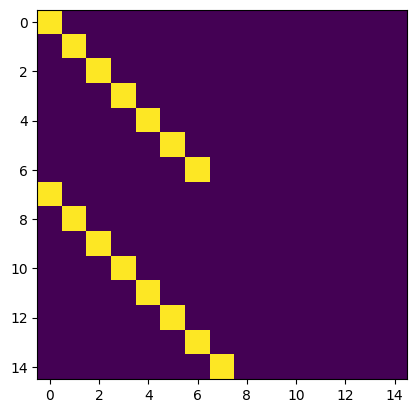

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(scores1.cpu().detach().numpy()[0,:,:])


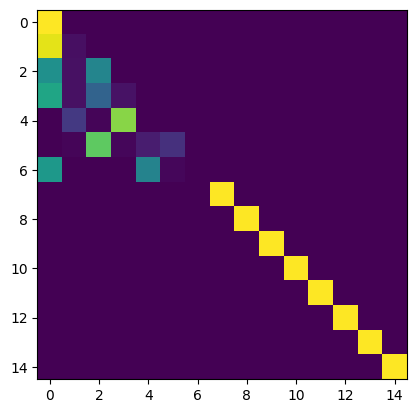

In [ ]:
plt.imshow(scores2.cpu().detach().numpy()[0,:,:])

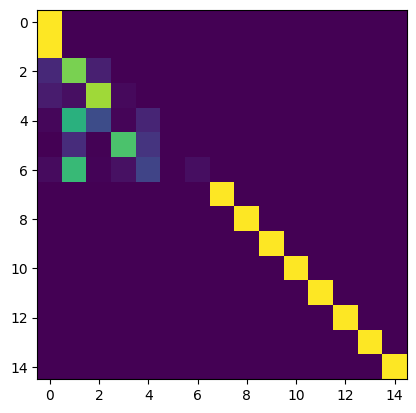

In [ ]:
plt.imshow(scores2.cpu().detach().numpy()[1,:,:])

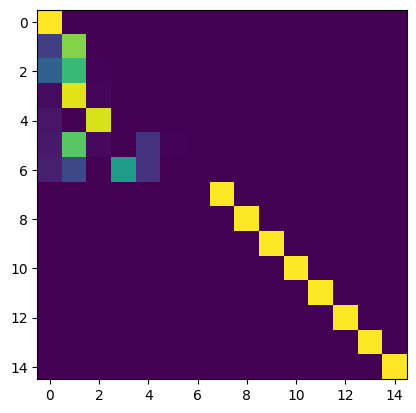

In [ ]:
plt.imshow(scores2.cpu().detach().numpy()[2,:,:])

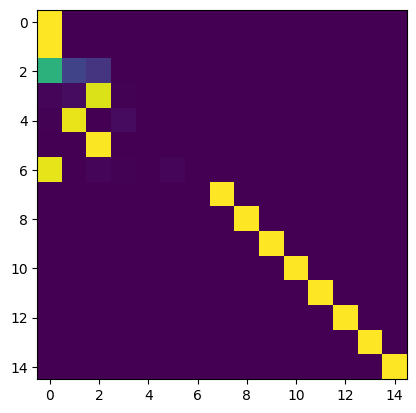

In [ ]:
plt.imshow(scores2.cpu().detach().numpy()[3,:,:])

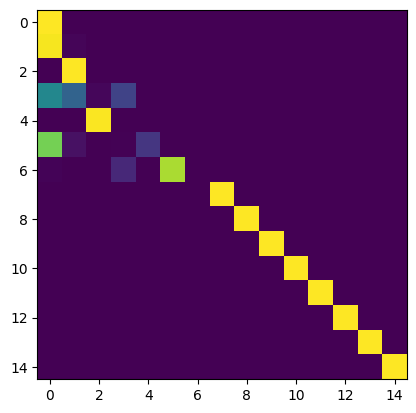

In [ ]:
plt.imshow(scores2.cpu().detach().numpy()[4,:,:])

In [ ]:
# across 1000 score1 and score2

In [ ]:
new_input = make_synthetic_data(52, 16, 1000)
new_x = new_input[:,:-1]
new_y = new_input[:,1:]

In [ ]:
output, scores1, scores2 = model2.forward(new_x.to(device))

In [ ]:
print(scores1.shape)
acc_score1 = scores1.mean(dim=0)
acc_score2 = scores2.mean(dim=0)

torch.Size([1000, 15, 15])


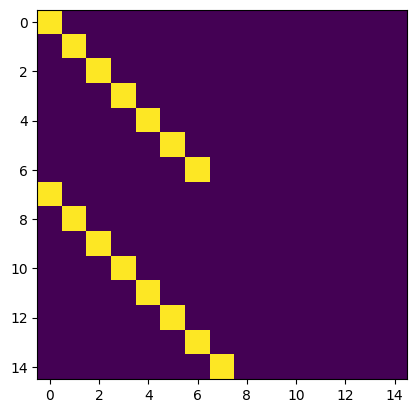

In [ ]:
plt.imshow(acc_score1.cpu().detach().numpy()[:,:])

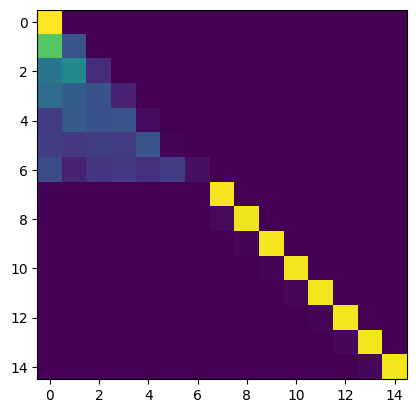

In [ ]:
plt.imshow(acc_score2.cpu().detach().numpy()[:,:])

In [ ]:
acc_score1

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00],
        [7.6778e-05, 9.9992e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.9010e-05, 3.2065e-07, 9.9998e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00],
        [5.4249e-05, 8.4165e-06, 1.4391e-07, 9.9994e-01, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.2027e-07, 1.5332e-09, 6.7182e-08, 1.6153e-07, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
      

In [ ]:
# we will try to zero out the layer 1 values and then check the layer 2 values

In [ ]:
# we will ablate the first layer values

In [ ]:
from math import sqrt
# transformer

class TwoLayerTransformer(nn.Module):

  def __init__(self, vocab_size, seq_length, embedding_dim = 64, d_head = 64):
    super().__init__()
    self.vocab_size = vocab_size
    self.seq_length = seq_length
    self.embedding_dim = embedding_dim
    self.d_head = d_head
    self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
    self.pos_embedding = nn.Embedding(seq_length-1, embedding_dim)
    self.W_Q1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V1 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_Q2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_K2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.W_V2 = nn.Linear(embedding_dim, d_head, bias=False)
    self.output_projection = nn.Linear(d_head, vocab_size)



  def forward(self, inputs, ablate_layer1=False): # inputs : (batch_size, seq_length-1)

    # first layer
    positions = torch.arange(self.seq_length-1).to(device)
    input_token_embeddings = self.token_embedding(inputs)
    input_pos_embeddings = self.pos_embedding(positions)
    input_final_embedding = input_token_embeddings + input_pos_embeddings # batch_size, seq_len-1, num_dim
    Q = self.W_Q1(input_final_embedding)
    K = self.W_K1(input_final_embedding)
    V = self.W_V1(input_final_embedding) # batch_size, seq_len-1, d_head
    # find attention
    scores1 = Q @ K.transpose(-1, -2)
    scores1 /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores1 = scores1.masked_fill(mask, float("-inf"))
    scores1 = torch.softmax(scores1, dim=-1) # batch_Size, seq_len-1, seq_len-1
    if ablate_layer1:
        values1 = input_final_embedding
    else:
        values1 = scores1 @ V + input_final_embedding

    # second layer
    Q = self.W_Q2(values1)
    K = self.W_K2(values1)
    V = self.W_V2(values1) # batch_size, seq_len-1, d_head
    # find attention
    scores2 = Q @ K.transpose(-1, -2)
    scores2 /= sqrt(self.d_head)
    # make masked head
    mask = torch.triu(torch.ones(self.seq_length-1, self.seq_length-1), diagonal=1).bool().to(device)
    scores2 = scores2.masked_fill(mask, float("-inf"))
    scores2 = torch.softmax(scores2, dim=-1) # batch_Size, seq_len-1, seq_len-1
    values = scores2 @ V + values1 # batch_size, seq_len-1, d_head

    return self.output_projection(values), scores1, scores2



In [ ]:
# save trained weights
state_dict = model2.state_dict()

# reinstantiate with new class definition
model2 = TwoLayerTransformer(vocab_size, seq_length, embedding_dim, d_head).to(device)

# reload trained weights
model2.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
# evaluation
model2.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    output,_,_ = model2.forward(x, ablate_layer1=True)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


10000
tensor([5.7129, 5.8321, 6.0989, 5.9295, 6.0160, 6.1245, 5.9521, 6.2424, 5.8504,
        6.0410, 5.8617, 6.1841, 6.0710, 6.2139, 5.9430])


In [ ]:
# evaluation
model2.eval()
loss_func = torch.nn.CrossEntropyLoss(reduction='none')
loss_values = torch.zeros(15)
count = 0
with torch.no_grad():
  for batch_idx, (x, y) in enumerate(train_loader):
    x = x.to(device)
    output,_,_ = model2.forward(x, ablate_layer1=False)
    # loss
    losses = loss_func(output.transpose(-1, -2), y.to(device))
    for loss in losses:
      count += 1
      loss_values += loss.cpu()
    # if batch_idx %5 == 0:
    #   print(f"batch: {epoch}, loss = {loss}")
print(count)
print(loss_values/count)


10000
tensor([3.9311e+00, 3.9012e+00, 3.8899e+00, 3.8885e+00, 3.8818e+00, 3.8718e+00,
        3.8661e+00, 6.2977e-02, 4.5911e-03, 3.3312e-03, 3.9053e-03, 3.6631e-03,
        3.8112e-03, 3.2060e-03, 3.4641e-03])
